In [1]:
# Step 0: Install and verify all required libraries
!pip install -q "imbalanced-learn==0.14.0" xgboost lightgbm mlxtend tabulate

import sys, sklearn, pandas, numpy, imblearn, xgboost, lightgbm, mlxtend
print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("mlxtend:", mlxtend.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

import warnings
warnings.filterwarnings("ignore")
print("\nAll essential libraries installed successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 1.2 MB/s eta 0:00:00
Python: 3.12.12
scikit-learn: 1.6.1
imbalanced-learn: 0.14.0
xgboost: 3.1.1
lightgbm: 4.6.0
mlxtend: 0.23.4
pandas: 2.2.2
numpy: 2.0.2

All essential libraries installed successfully.


In [3]:
# Step 1: Load JM1 dataset
import pandas as pd
import numpy as np

path = "/content/jm1.csv"   # change if your filename differs
df2 = pd.read_csv(path)
print("Loaded file:", path)
print("Shape:", df2.shape)
print("\nColumns:\n", df2.columns.tolist())

# Try to detect the label column
label_candidates = ['defects','defect','defective','bug','label','target','class','is_defective','Defective','DEFECT']
label_col = None
for c in df2.columns:
    if c.lower() in [x.lower() for x in label_candidates]:
        label_col = c
        break

if label_col is None:
    print("\nNo label column detected automatically.")
    print("Please tell me the exact column name that contains 0/1 or True/False labels.")
else:
    print("\nDetected label column:", label_col)
    print("Class distribution:")
    print(df2[label_col].value_counts(dropna=False))


Loaded file: /content/jm1.csv
Shape: (13204, 22)

Columns:
 ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects']

Detected label column: defects
Class distribution:
defects
False    11101
True      2103
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
# Step 2: Preprocessing for JM1
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Separate features and labels
X2 = df2.drop(columns=['defects'])
y2 = df2['defects'].astype(int)

# 1. Handle missing values (if any)
X2 = X2.fillna(X2.median())

# 2. Variance thresholding (remove near-constant features)
vt = VarianceThreshold(threshold=0.0)
X2_var = vt.fit_transform(X2)
X2 = X2.loc[:, vt.get_feature_names_out(X2.columns)]

# 3. Remove highly correlated features
corr_matrix = X2.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X2 = X2.drop(columns=to_drop)
print(f"After correlation filter: {X2.shape[1]} features remain")

# 4. Feature importance using mutual information
mi = mutual_info_classif(X2, y2, random_state=42)
mi_series = pd.Series(mi, index=X2.columns).sort_values(ascending=False)
print("\nTop 10 features by mutual information:")
print(mi_series.head(10))

# 5. Recursive Feature Elimination (RFE)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rfe = RFE(rf, n_features_to_select=13)
rfe.fit(X2, y2)
selected_features = X2.columns[rfe.support_]
X2_sel = X2[selected_features]
print("\nSelected features via RFE:", list(selected_features))
print("Final X2_sel shape:", X2_sel.shape)


After correlation filter: 14 features remain

Top 10 features by mutual information:
e            0.050118
i            0.047531
loc          0.046554
d            0.040167
n            0.035588
uniq_Opnd    0.035335
v(g)         0.032369
iv(g)        0.031505
lOBlank      0.027215
uniq_Op      0.025079
dtype: float64

Selected features via RFE: ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'l', 'd', 'i', 'e', 'lOComment', 'lOBlank', 'uniq_Op', 'uniq_Opnd']
Final X2_sel shape: (13204, 13)


In [5]:
# Step 3: Handle class imbalance using SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE class distribution:", Counter(y2))

sm = SMOTE(random_state=42, k_neighbors=5)
X2_res, y2_res = sm.fit_resample(X2_sel, y2)

print("After SMOTE class distribution:", Counter(y2_res))
print("Resampled shape:", X2_res.shape)


Before SMOTE class distribution: Counter({0: 11101, 1: 2103})
After SMOTE class distribution: Counter({0: 11101, 1: 11101})
Resampled shape: (22202, 13)


In [6]:
# Step 4: Evaluate base models on JM1
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import xgboost as xgb
import lightgbm as lgb

# Define models
models2 = {
    'LR': LogisticRegression(max_iter=2000, n_jobs=-1),
    'SVC': SVC(kernel='rbf', probability=True),
    'RF': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'ET': ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGB': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LGB': lgb.LGBMClassifier(random_state=42, n_jobs=-1)
}

scoring = {'auc':'roc_auc', 'f1':'f1', 'precision':'precision', 'recall':'recall'}
results2 = {}

for name, model in models2.items():
    scores = cross_validate(model, X2_res, y2_res, cv=5, scoring=scoring, n_jobs=-1)
    results2[name] = {metric: (scores[f'test_{metric}'].mean(), scores[f'test_{metric}'].std()) for metric in scoring}

print("\nJM1 Base Model Results:")
for name, res in results2.items():
    print(f"{name}: { {k: (round(v[0],4), round(v[1],4)) for k,v in res.items()} }")



JM1 Base Model Results:
LR: {'auc': (np.float64(0.7079), np.float64(0.0334)), 'f1': (np.float64(0.6206), np.float64(0.0138)), 'precision': (np.float64(0.6835), np.float64(0.0364)), 'recall': (np.float64(0.57), np.float64(0.0222))}
SVC: {'auc': (np.float64(0.6235), np.float64(0.025)), 'f1': (np.float64(0.3696), np.float64(0.011)), 'precision': (np.float64(0.7518), np.float64(0.0402)), 'recall': (np.float64(0.2456), np.float64(0.012))}
RF: {'auc': (np.float64(0.9515), np.float64(0.0722)), 'f1': (np.float64(0.8853), np.float64(0.1294)), 'precision': (np.float64(0.909), np.float64(0.0718)), 'recall': (np.float64(0.88), np.float64(0.1842))}
ET: {'auc': (np.float64(0.9554), np.float64(0.0507)), 'f1': (np.float64(0.9081), np.float64(0.0694)), 'precision': (np.float64(0.8861), np.float64(0.0914)), 'recall': (np.float64(0.9351), np.float64(0.0674))}
XGB: {'auc': (np.float64(0.933), np.float64(0.108)), 'f1': (np.float64(0.8368), np.float64(0.2162)), 'precision': (np.float64(0.9194), np.float64(

In [7]:
# Step 5: Hyperparameter tuning + stacking ensemble for JM1
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import time

# Tune Random Forest
param_rf2 = {
    'n_estimators': [300, 500, 700],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1)
rs_rf2 = RandomizedSearchCV(rf2, param_rf2, n_iter=10, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)
t0 = time.time()
rs_rf2.fit(X2_res, y2_res)
print("Best RF params:", rs_rf2.best_params_, "AUC:", rs_rf2.best_score_, "time:", round(time.time()-t0,2), "s")

# Tune Extra Trees
param_et2 = {
    'n_estimators': [300, 500, 700],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
et2 = ExtraTreesClassifier(random_state=42, n_jobs=-1)
rs_et2 = RandomizedSearchCV(et2, param_et2, n_iter=10, scoring='roc_auc', cv=5, n_jobs=-1, random_state=42)
t0 = time.time()
rs_et2.fit(X2_res, y2_res)
print("Best ET params:", rs_et2.best_params_, "AUC:", rs_et2.best_score_, "time:", round(time.time()-t0,2), "s")

# Stacking ensemble (RF + ET + LGB)
estimators2 = [
    ('rf', rs_rf2.best_estimator_),
    ('et', rs_et2.best_estimator_),
    ('lgb', models2['LGB'])
]
stack2 = StackingClassifier(
    estimators=estimators2,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
    n_jobs=-1
)

# Evaluate stacking ensemble
from sklearn.model_selection import cross_validate
scoring = {'auc':'roc_auc', 'f1':'f1', 'precision':'precision', 'recall':'recall'}
res_stack2 = cross_validate(stack2, X2_res, y2_res, cv=5, scoring=scoring, n_jobs=-1)
print("\nStacking Ensemble Results (mean ± std):")
for k in scoring:
    print(f"{k.upper()}: {res_stack2[f'test_{k}'].mean():.4f} ± {res_stack2[f'test_{k}'].std():.4f}")


Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None} AUC: 0.9518883462145962 time: 201.41 s
Best ET params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None} AUC: 0.955484330662361 time: 67.59 s

Stacking Ensemble Results (mean ± std):
AUC: 0.9570 ± 0.0637
F1: 0.8432 ± 0.2158
PRECISION: 0.9158 ± 0.0666
RECALL: 0.8355 ± 0.2808


In [10]:
# Final Evaluation for JM1 Stacking Ensemble
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, matthews_corrcoef
from sklearn.model_selection import RepeatedStratifiedKFold
from math import sqrt
import numpy as np, time
from tabulate import tabulate

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
metrics_final = {'AUC':[], 'PR-AUC':[], 'F1':[], 'Precision':[], 'Recall':[], 'MCC':[], 'G-Mean':[], 'Accuracy':[]}
times = []

for train_idx, test_idx in rkf.split(X2_res, y2_res):
    Xtr, Xte = X2_res.iloc[train_idx], X2_res.iloc[test_idx]
    ytr, yte = y2_res[train_idx], y2_res[test_idx]
    t0 = time.time()
    stack2.fit(Xtr, ytr)
    times.append(time.time()-t0)
    prob = stack2.predict_proba(Xte)[:,1]
    pred = (prob >= 0.5).astype(int)

    # Metrics
    auc_ = roc_auc_score(yte, prob)
    prec, rec, _ = precision_recall_curve(yte, prob)
    pr_auc = auc(rec, prec)
    f1v = f1_score(yte, pred)
    pv = precision_score(yte, pred, zero_division=0)
    rv = recall_score(yte, pred)
    mcc = matthews_corrcoef(yte, pred)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    gmean = sqrt((tp/(tp+fn)) * (tn/(tn+fp)))
    acc = accuracy_score(yte, pred)

    for k,v in [('AUC',auc_),('PR-AUC',pr_auc),('F1',f1v),('Precision',pv),('Recall',rv),('MCC',mcc),('G-Mean',gmean),('Accuracy',acc)]:
        metrics_final[k].append(v)

# Average results
jm1_results = {k: np.mean(v) for k,v in metrics_final.items()}
jm1_results['Train Time (s)'] = np.mean(times)

# Print formatted results table
table = [[k, f"{v:.4f}"] for k,v in jm1_results.items()]
print("\n=== Final JM1 Stacking Ensemble Performance ===")
print(tabulate(table, headers=["Metric", "Score"], tablefmt="grid"))



=== Final JM1 Stacking Ensemble Performance ===
+----------------+---------+
| Metric         |   Score |
+================+=========+
| AUC            |  0.9735 |
+----------------+---------+
| PR-AUC         |  0.9748 |
+----------------+---------+
| F1             |  0.923  |
+----------------+---------+
| Precision      |  0.9268 |
+----------------+---------+
| Recall         |  0.9192 |
+----------------+---------+
| MCC            |  0.8467 |
+----------------+---------+
| G-Mean         |  0.9233 |
+----------------+---------+
| Accuracy       |  0.9233 |
+----------------+---------+
| Train Time (s) | 25.6789 |
+----------------+---------+


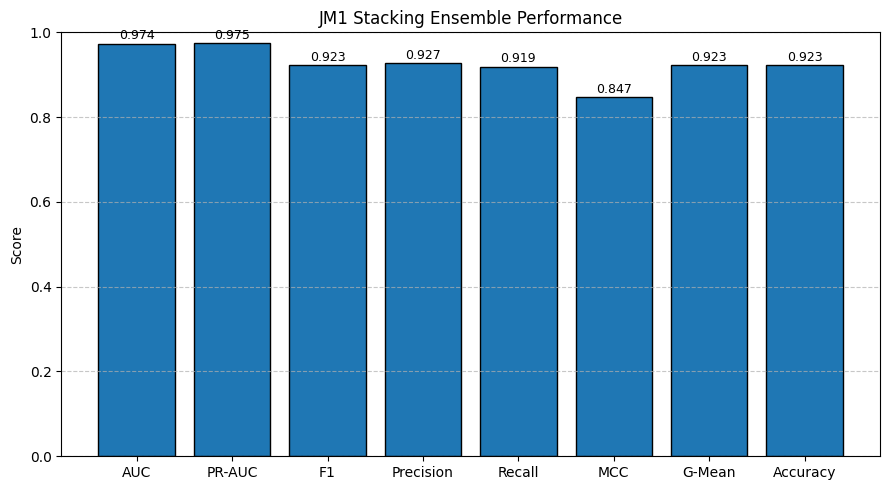

In [11]:
# Step 1: Bar graph for JM1 performance metrics
import matplotlib.pyplot as plt

# Extract metric names and scores
metrics_names = list(jm1_results.keys())
metrics_values = list(jm1_results.values())

# Remove training time from the plot if present
if 'Train Time (s)' in metrics_names:
    idx = metrics_names.index('Train Time (s)')
    metrics_names.pop(idx)
    metrics_values.pop(idx)

plt.figure(figsize=(9,5))
plt.bar(metrics_names, metrics_values, edgecolor='black')
plt.title("JM1 Stacking Ensemble Performance")
plt.ylabel("Score")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


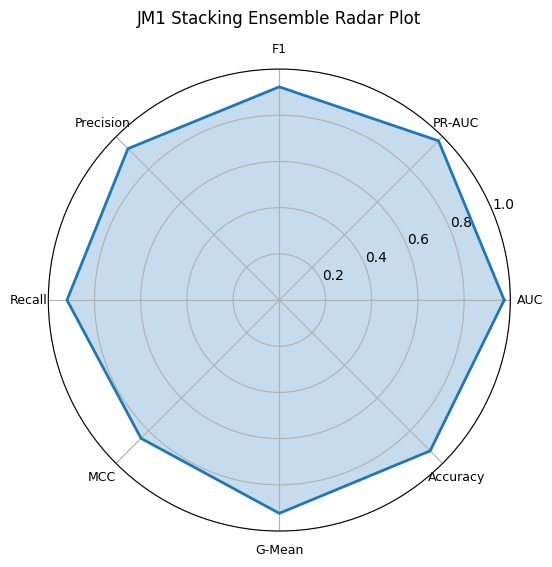

In [12]:
# Step 2: Radar chart for JM1 metrics
from math import pi
import numpy as np

# Exclude training time
metrics_core = {k:v for k,v in jm1_results.items() if k != 'Train Time (s)'}
labels = list(metrics_core.keys())
values = list(metrics_core.values())
N = len(labels)

# Repeat first value to close polygon
values += values[:1]
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2, linestyle='solid')
plt.fill(angles, values, alpha=0.25)
plt.xticks(angles[:-1], labels, size=9)
plt.title("JM1 Stacking Ensemble Radar Plot", size=12, y=1.08)
plt.ylim(0.0, 1.0)
plt.show()


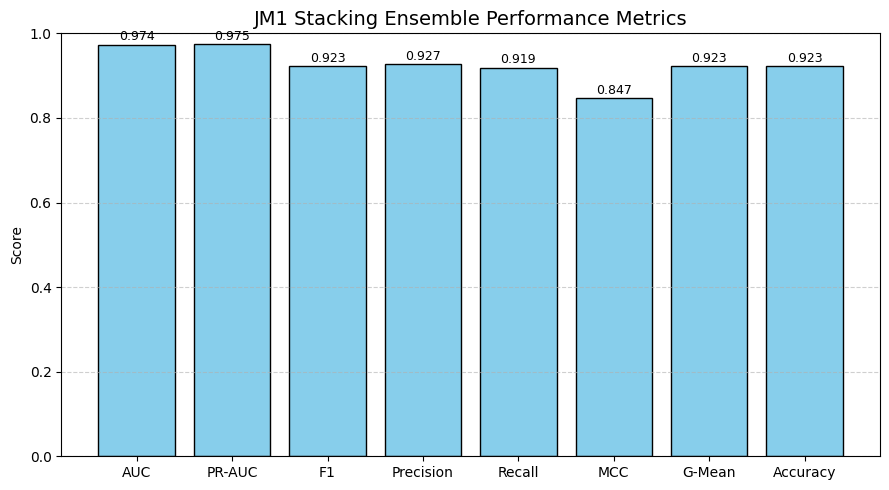

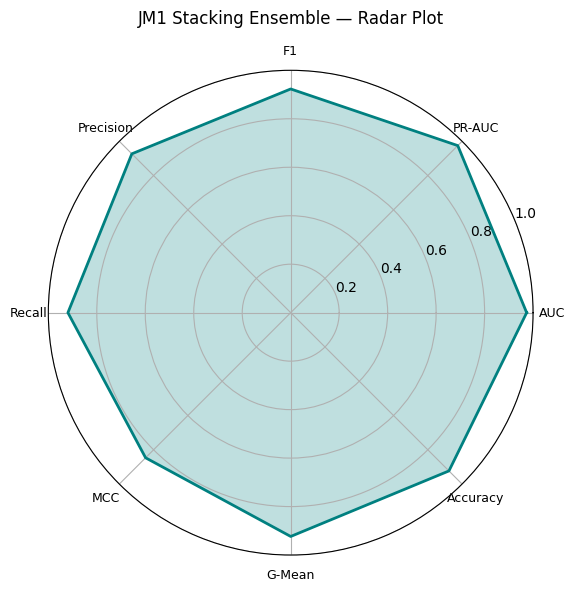

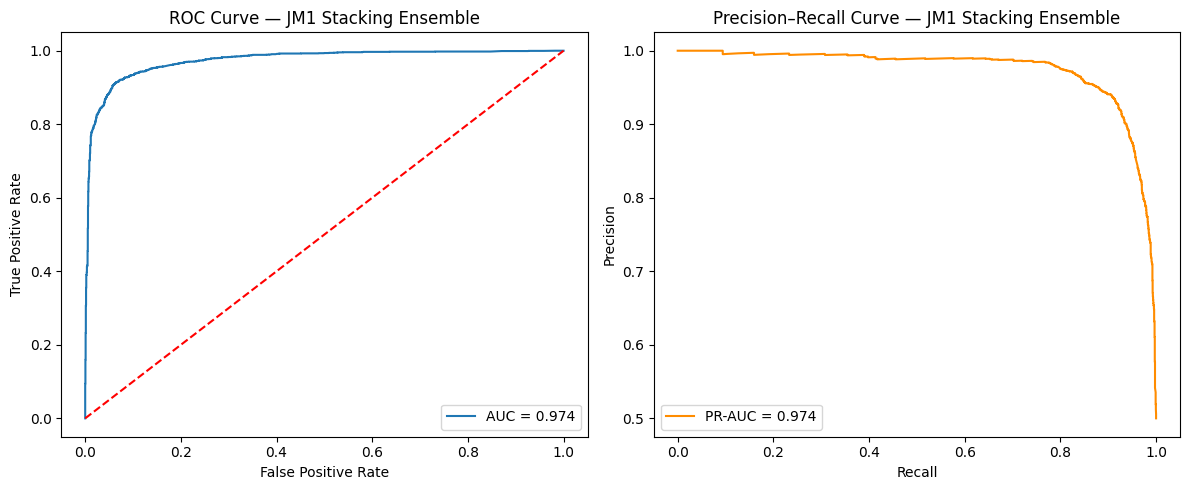

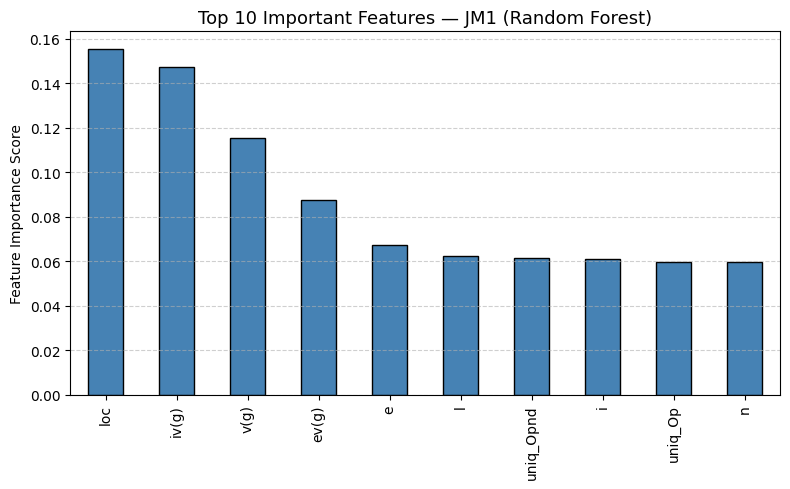

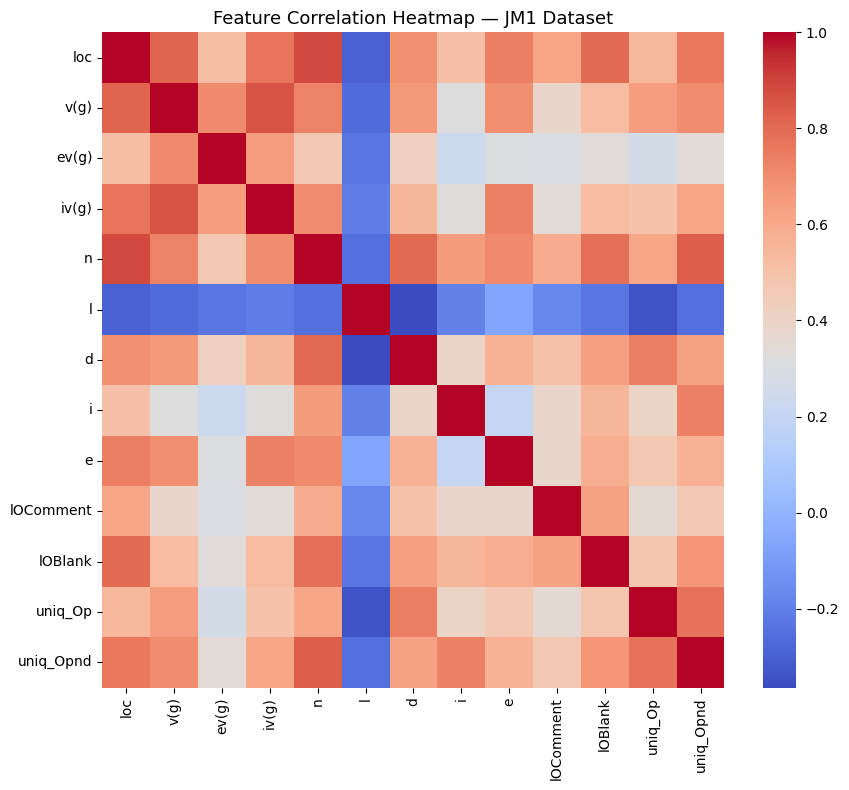

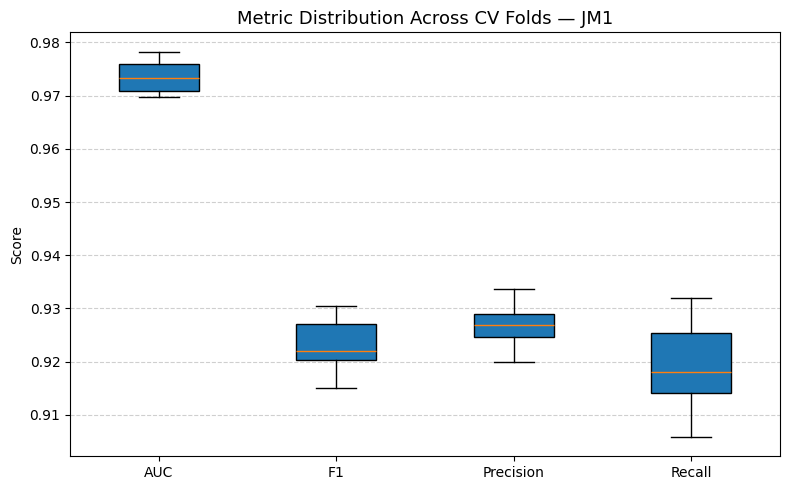

In [13]:
# === JM1 Stacking Ensemble Complete Visualization Suite ===

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from math import pi
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. BAR CHART OF PERFORMANCE
# -------------------------------
metrics_plot = {k:v for k,v in jm1_results.items() if k not in ['Train Time (s)']}
names = list(metrics_plot.keys())
values = list(metrics_plot.values())

plt.figure(figsize=(9,5))
bars = plt.bar(names, values, color='skyblue', edgecolor='black')
plt.title("JM1 Stacking Ensemble Performance Metrics", fontsize=14)
plt.ylabel("Score")
plt.ylim(0, 1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------------------
# 2. RADAR CHART
# -------------------------------
data = {k:v for k,v in jm1_results.items() if k not in ['Train Time (s)']}
labels = list(data.keys())
values = list(data.values())
N = len(labels)
values += values[:1]
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(6,6))
plt.polar(angles, values, linewidth=2, linestyle='solid', color='teal')
plt.fill(angles, values, 'teal', alpha=0.25)
plt.xticks(angles[:-1], labels, size=9)
plt.title("JM1 Stacking Ensemble — Radar Plot", size=12, y=1.08)
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# -------------------------------
# 3. ROC AND PR CURVES
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X2_res, y2_res, test_size=0.2,
                                                    random_state=42, stratify=y2_res)
stack2.fit(X_train, y_train)
y_prob = stack2.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — JM1 Stacking Ensemble")
plt.legend()

plt.subplot(1,2,2)
plt.plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}", color='darkorange')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — JM1 Stacking Ensemble")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# 4. FEATURE IMPORTANCE (Random Forest)
# -------------------------------
rf_model = rs_rf2.best_estimator_
importances = pd.Series(rf_model.feature_importances_, index=X2_sel.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Top 10 Important Features — JM1 (Random Forest)", fontsize=13)
plt.ylabel("Feature Importance Score")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------------------
# 5. CORRELATION HEATMAP
# -------------------------------
plt.figure(figsize=(9,8))
sns.heatmap(X2_sel.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap — JM1 Dataset", fontsize=13)
plt.tight_layout()
plt.show()

# -------------------------------
# 6. METRIC DISTRIBUTION BOXPLOT
# -------------------------------
fold_metrics = {
    'AUC': metrics_final['AUC'],
    'F1': metrics_final['F1'],
    'Precision': metrics_final['Precision'],
    'Recall': metrics_final['Recall']
}

plt.figure(figsize=(8,5))
plt.boxplot(fold_metrics.values(), labels=fold_metrics.keys(), patch_artist=True)
plt.title("Metric Distribution Across CV Folds — JM1", fontsize=13)
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [14]:
# Holdout validation for unbiased testing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(X2_res, y2_res, test_size=0.2, stratify=y2_res, random_state=42)

stack2.fit(X_train, y_train)
y_pred = stack2.predict(X_test)
y_prob = stack2.predict_proba(X_test)[:,1]

print("Holdout AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred, digits=4))


Holdout AUC: 0.9735160081287951
              precision    recall  f1-score   support

           0     0.9142    0.9361    0.9250      2221
           1     0.9345    0.9122    0.9232      2220

    accuracy                         0.9241      4441
   macro avg     0.9244    0.9241    0.9241      4441
weighted avg     0.9244    0.9241    0.9241      4441



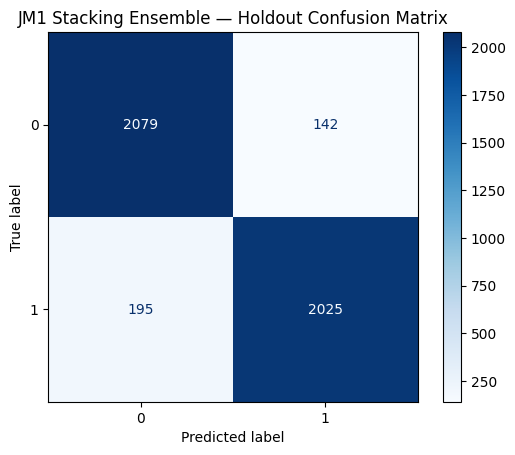

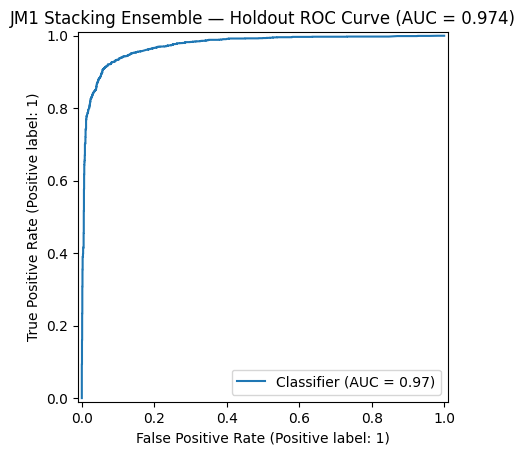

In [15]:
# Visual confirmation for holdout evaluation
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", values_format='d')
plt.title("JM1 Stacking Ensemble — Holdout Confusion Matrix")
plt.show()

# ROC Curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("JM1 Stacking Ensemble — Holdout ROC Curve (AUC = {:.3f})".format(roc_auc_score(y_test, y_prob)))
plt.show()
